In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Визначення функції вологості
def M(t):
    return 50 * np.exp(-0.1 * t) + 5 * np.sin(t)

# Аналітична похідна: M'(t) = -5*e^(-0.1t) + 5*cos(t)
def M_prime_exact(t):
    return -5 * np.exp(-0.1 * t) + 5 * np.cos(t)

t0 = 1.0
exact_val = M_prime_exact(t0)
print(f"Точне значення M'({t0}): {exact_val:.10f}") 

Точне значення M'(1.0): -1.8226755608


Оптимальний крок h0: 4.33e-06
Найкраща точність R0: 2.98e-11


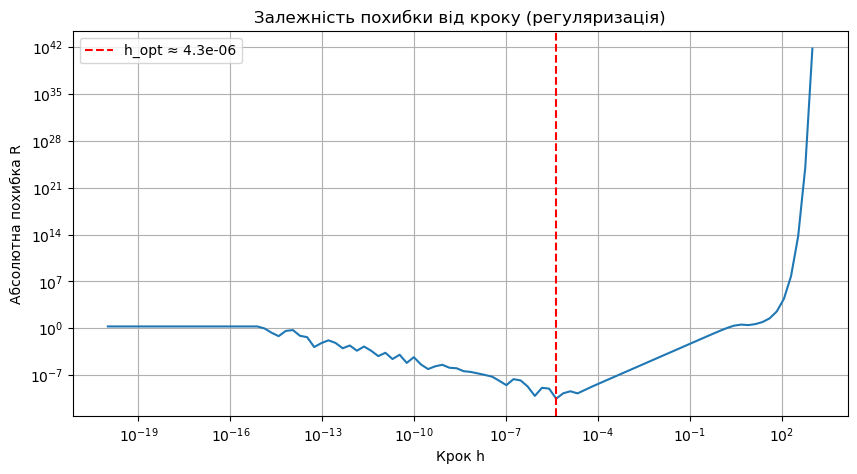

In [4]:
def central_difference(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

h_values = np.logspace(-20, 3, 100) # Від 10^-20 до 10^3
errors = []

for h in h_values:
    approx = central_difference(M, t0, h)
    errors.append(abs(approx - exact_val))

# Пошук оптимального кроку h0
min_error_idx = np.argmin(errors)
h0 = h_values[min_error_idx]
R0 = errors[min_error_idx]

print(f"Оптимальний крок h0: {h0:.2e}")
print(f"Найкраща точність R0: {R0:.2e}")

plt.figure(figsize=(10, 5))
plt.loglog(h_values, errors)
plt.xlabel('Крок h')
plt.ylabel('Абсолютна похибка R')
plt.title('Залежність похибки від кроку (регуляризація)')
plt.grid(True)
plt.axvline(h0, color='r', linestyle='--', label=f'h_opt ≈ {h0:.1e}')
plt.legend()
plt.show()

In [5]:
h_base = 1e-3

# Обчислення значень на двох сітках
D_h = central_difference(M, t0, h_base)
D_2h = central_difference(M, t0, 2 * h_base)

# Похибка для початкового кроку
R1 = abs(D_h - exact_val)

# Метод Рунге-Ромберга (p=2 для центральної різниці)
# y_R = D_h + (D_h - D_2h) / (q^p - 1), де q=2, p=2
y_R = D_h + (D_h - D_2h) / 3 
R2 = abs(y_R - exact_val)

print(f"D(h): {D_h:.10f}, R1: {R1:.2e}")
print(f"D_Runge: {y_R:.10f}, R2: {R2:.2e}")
print(f"Покращення точності: {R1/R2:.2f} разів")

D(h): -1.8226760186, R1: 4.58e-07
D_Runge: -1.8226755608, R2: 3.20e-12
Покращення точності: 143244.89 разів


In [6]:
D_4h = central_difference(M, t0, 4 * h_base)

# Уточнене значення за Ейткеном 
numerator = (D_2h**2) - (D_4h * D_h)
denominator = 2 * D_2h - (D_4h + D_h)
y_E = numerator / denominator

# Оцінка порядку точності p 
p = np.log(abs((D_4h - D_2h) / (D_2h - D_h))) / np.log(2)

R3 = abs(y_E - exact_val)

print(f"D_Aitken: {y_E:.10f}, R3: {R3:.2e}")
print(f"Визначений порядок точності p: {p:.4f}")

D_Aitken: -1.8226755609, R3: 2.19e-11
Визначений порядок точності p: 2.0000
